In [5]:
# Function definitions and imports
import os
import re
import cv2
import numpy as np
from datetime import datetime, timedelta
from scipy.signal import find_peaks, peak_widths
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import pandas as pd

# Parameters (CHANGE)
parent_folder = "/Volumes/D06V1/D06V1/OSC_Videos/2026ab/"
peak_threshold = 3.5  # V, for peak detection in Vpp signal
max_files = 3  # Set to a number to limit files per folder, or None to process all
# max_files = None  # Uncomment to process all files
profile_threshold = 1000  # Threshold for red pixel count in vertical profile to determine peak width

# Parameters (DO NOT CHANGE)
grid_height_px = 3.95/5.56*400/10  # for one grid corresponding to 2 V
v_div = 2.0
fps = 20.0

def extract_datetime_from_filename(filename):
    """Extract YYYYMMDD_HHMMSS from filename."""
    match = re.search(r"(\d{8})_(\d{6})", filename)
    if not match:
        return None
    date_part, time_part = match.groups()
    return datetime.strptime(date_part + time_part, "%Y%m%d%H%M%S")


def compute_vpp_series_for_file(file_path, v_div=2.0, fps=20.0, threshold=1000):
    """Compute Vpp for CH3 (red trace) per frame using threshold-based width calculation."""

    cap = cv2.VideoCapture(file_path)
    volts_per_pixel = v_div / (3.95/5.56*400/10)

    vpp_series = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        height, width, _ = frame.shape
        roi = frame[int(height * 0.2):int(height * 0.8), int(width * 0.1):int(width * 0.9)]

        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

        # CH3: red trace (HSV hue wraps around 0)
        mask1 = cv2.inRange(hsv, np.array([0, 100, 100]), np.array([10, 255, 255]))
        mask2 = cv2.inRange(hsv, np.array([160, 100, 100]), np.array([180, 255, 255]))
        red_mask = cv2.bitwise_or(mask1, mask2)

        # Create 1D vertical profile by summing red pixels along x-axis
        vertical_profile = np.sum(red_mask, axis=1)
        
        # Smooth the profile to handle noise
        smooth_profile = gaussian_filter1d(vertical_profile.astype(float), sigma=2.0)
        
        # Threshold-based width calculation: find y-positions where red pixel count > threshold
        above_threshold = smooth_profile > threshold
        
        if np.any(above_threshold):
            # Find y-positions where red pixel count exceeds threshold
            threshold_positions = np.where(above_threshold)[0]
            
            # Get outermost y-positions (min and max)
            left_bound = threshold_positions[0]
            right_bound = threshold_positions[-1]
            
            # Calculate width in pixels
            peak_width_pixels = right_bound - left_bound
            
            vpp_series.append(peak_width_pixels * volts_per_pixel)
        else:
            vpp_series.append(np.nan)

        frame_idx += 1

    cap.release()

    # Time axis: frame_idx / fps in seconds
    time_series_sec = np.arange(len(vpp_series)) / fps

    return time_series_sec, np.array(vpp_series)

Found 30 folder(s) in: /Volumes/D06V1/D06V1/OSC_Videos/2026ab/

[1/30] Processing folder: 20260126
Found 0 total video file(s)
  ⚠ No .mkv files found, skipping folder

[2/30] Processing folder: 20260127
Found 0 total video file(s)
  ⚠ No .mkv files found, skipping folder

[3/30] Processing folder: 20260128
Found 0 total video file(s)
  ⚠ No .mkv files found, skipping folder

[4/30] Processing folder: 20260129
Found 0 total video file(s)
  ⚠ No .mkv files found, skipping folder

[5/30] Processing folder: 20260130
Found 0 total video file(s)
  ⚠ No .mkv files found, skipping folder

[6/30] Processing folder: 20260131
Found 0 total video file(s)
  ⚠ No .mkv files found, skipping folder

[7/30] Processing folder: 20260201
Found 0 total video file(s)
  ⚠ No .mkv files found, skipping folder

[8/30] Processing folder: 20260202
Found 0 total video file(s)
  ⚠ No .mkv files found, skipping folder

[9/30] Processing folder: 20260203
Found 0 total video file(s)
  ⚠ No .mkv files found, skipping

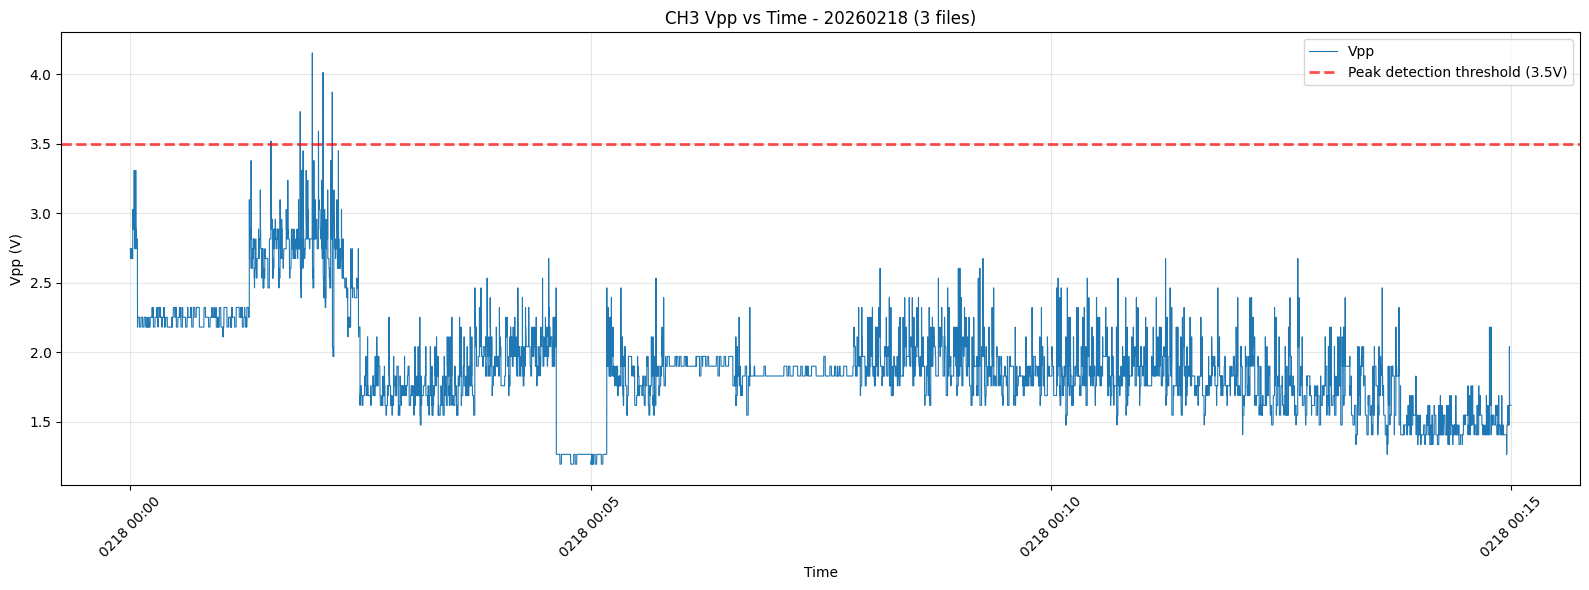


Found 6 peak(s) with Vpp > 3.5 V

PEAK SUMMARY
Peak 1: 2026-02-18 00:01:31 → Vpp = 3.5190 V
Peak 2: 2026-02-18 00:01:50 → Vpp = 3.7301 V
Peak 3: 2026-02-18 00:01:58 → Vpp = 4.1524 V
Peak 4: 2026-02-18 00:02:02 → Vpp = 3.5894 V
Peak 5: 2026-02-18 00:02:05 → Vpp = 4.0116 V
Peak 6: 2026-02-18 00:02:11 → Vpp = 3.8709 V

✓ Peak summary saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260218_peak_summary.csv
✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260218_peak_summary_plot.png

✓ Folder '20260218' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260218

[25/30] Processing folder: 20260219
Found 288 total video file(s)
Processing 3 file(s) (limited by max_files=3)

[1/3] 20260219_000000_n.mkv
  ✓ Vpp range: 2.111 - 3.026 V

[2/3] 20260219_000500_n.mkv
  ✓ Vpp range: 2.111 - 2.745 V

[3/3] 20260219_001000_n.mkv
  ✓ Vpp range: 1.971 - 2.815 V

COMBINED DATA: 18000 samples
Vpp range: 1.971 - 3.026 V
Time span: 2026-02-19 00:00:00 to 

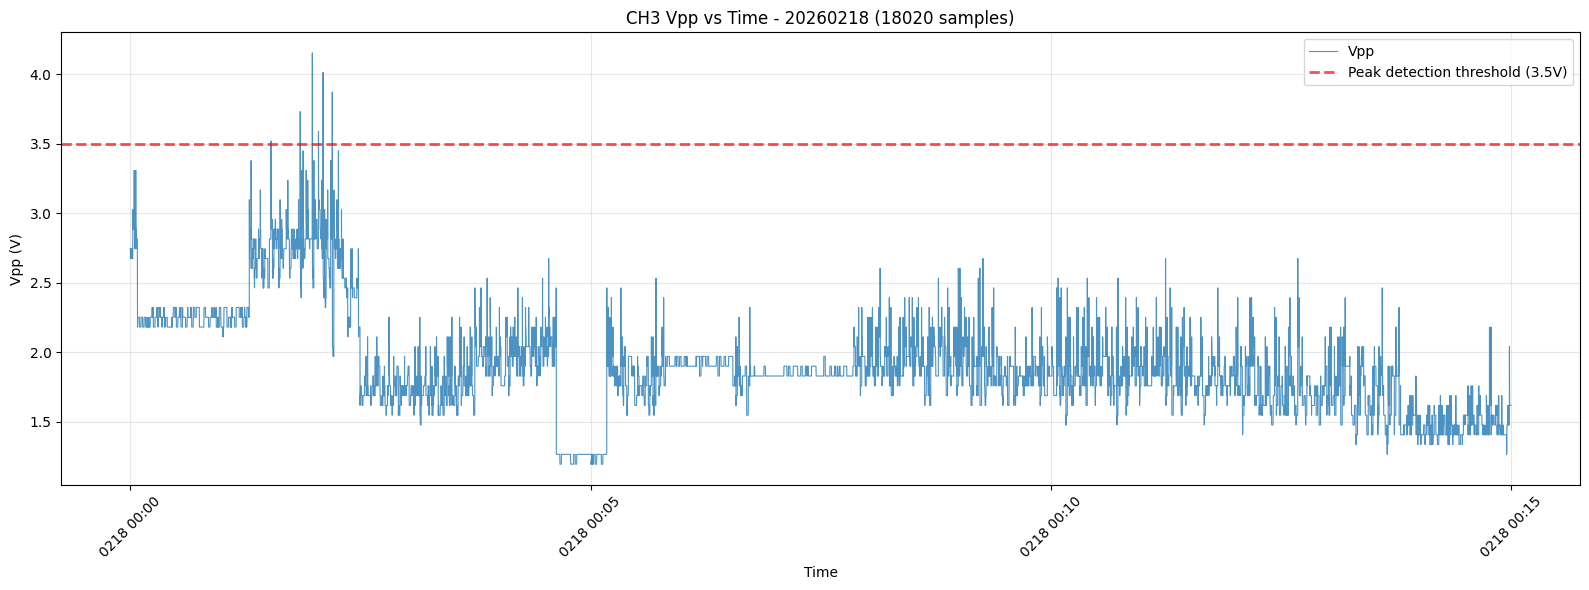

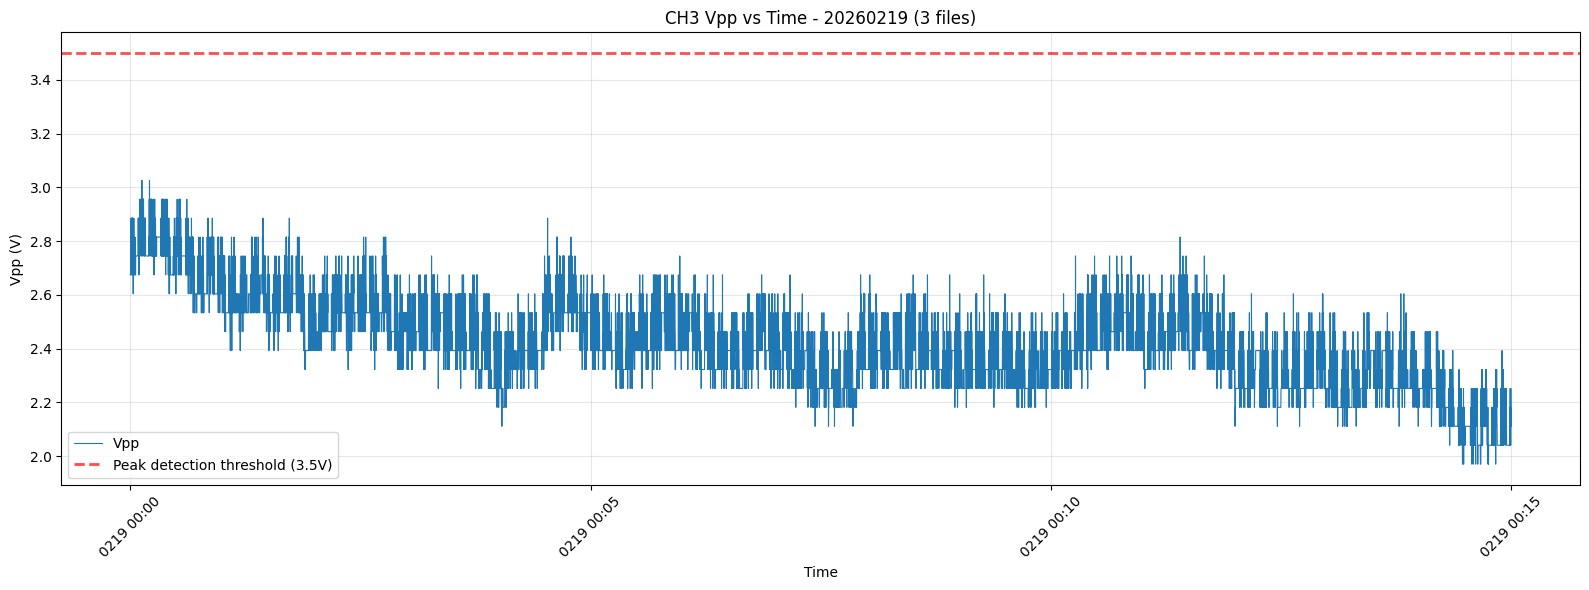


Found 0 peak(s) with Vpp > 3.5 V
No peaks found for this folder

✓ Folder '20260219' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260219

[26/30] Processing folder: 20260220
Found 288 total video file(s)
Processing 3 file(s) (limited by max_files=3)

[1/3] 20260220_000000_n.mkv
  ✓ Vpp range: 1.619 - 2.182 V

[2/3] 20260220_000500_n.mkv
  ✓ Vpp range: 1.337 - 2.111 V

[3/3] 20260220_001000_n.mkv
  ✓ Vpp range: 1.408 - 2.041 V

COMBINED DATA: 17999 samples
Vpp range: 1.337 - 2.182 V
Time span: 2026-02-20 00:00:00 to 2026-02-20 00:14:59.950000


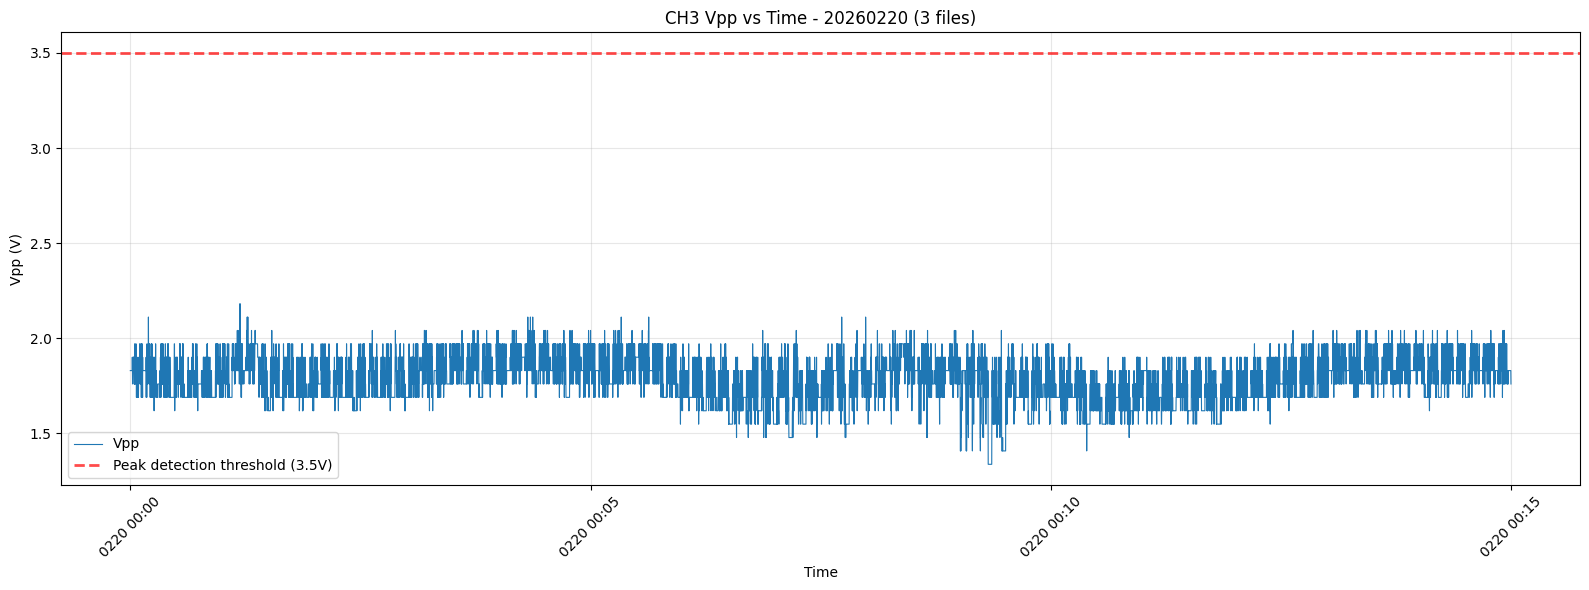


Found 0 peak(s) with Vpp > 3.5 V
No peaks found for this folder

✓ Folder '20260220' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260220

[27/30] Processing folder: 20260221
Found 288 total video file(s)
Processing 3 file(s) (limited by max_files=3)

[1/3] 20260221_000000_n.mkv
  ✓ Vpp range: 1.971 - 3.308 V

[2/3] 20260221_000500_n.mkv
  ✓ Vpp range: 2.393 - 3.237 V

[3/3] 20260221_001000_n.mkv
  ✓ Vpp range: 2.604 - 3.378 V

COMBINED DATA: 18000 samples
Vpp range: 1.971 - 3.378 V
Time span: 2026-02-21 00:00:00 to 2026-02-21 00:14:59.950000


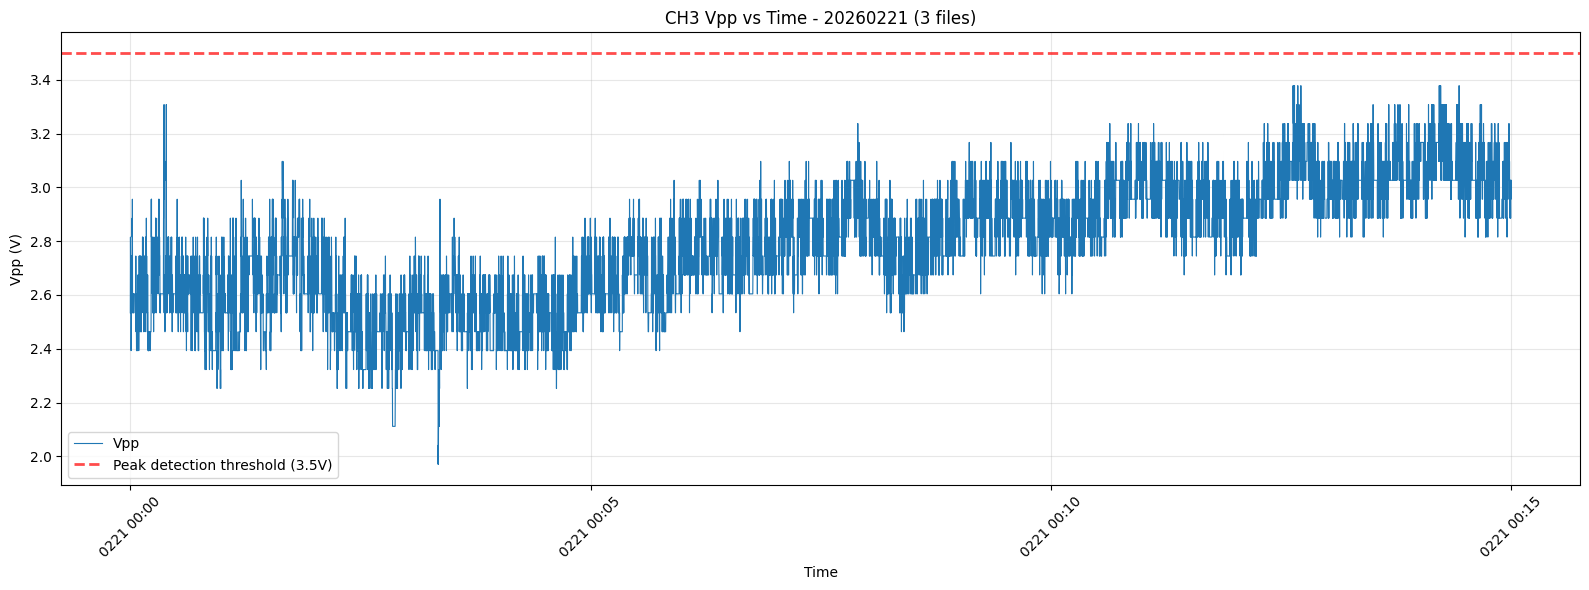


Found 0 peak(s) with Vpp > 3.5 V
No peaks found for this folder

✓ Folder '20260221' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260221

[28/30] Processing folder: 20260222
Found 288 total video file(s)
Processing 3 file(s) (limited by max_files=3)

[1/3] 20260222_000000_n.mkv
  ✓ Vpp range: 1.408 - 1.408 V

[2/3] 20260222_000500_n.mkv
  ✓ Vpp range: 1.267 - 2.393 V

[3/3] 20260222_001000_n.mkv
  ✓ Vpp range: 1.196 - 2.041 V

COMBINED DATA: 18019 samples
Vpp range: 1.196 - 2.393 V
Time span: 2026-02-22 00:00:00 to 2026-02-22 00:14:59.950000


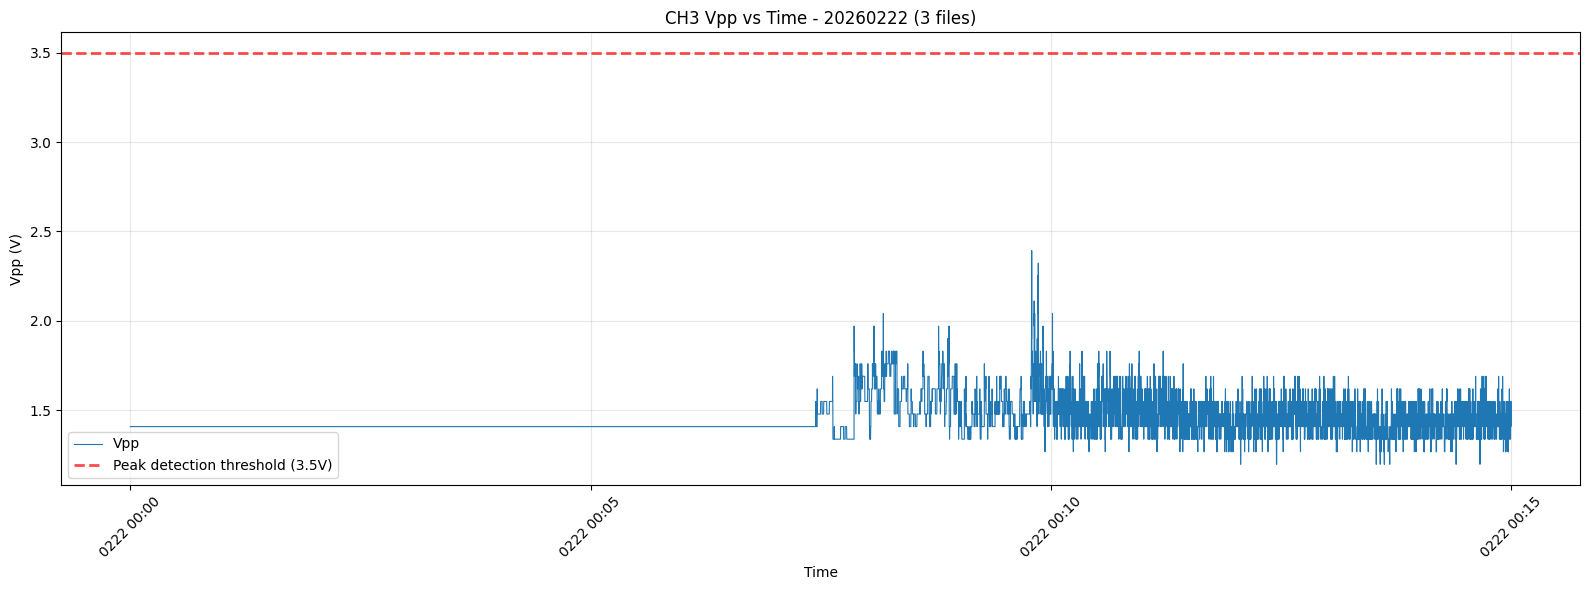


Found 0 peak(s) with Vpp > 3.5 V
No peaks found for this folder

✓ Folder '20260222' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260222

[29/30] Processing folder: 20260223
Found 288 total video file(s)
Processing 3 file(s) (limited by max_files=3)

[1/3] 20260223_000000_n.mkv
  ✓ Vpp range: 1.267 - 1.971 V

[2/3] 20260223_000500_n.mkv
  ✓ Vpp range: 1.337 - 1.971 V

[3/3] 20260223_001000_n.mkv
  ✓ Vpp range: 1.267 - 1.900 V

COMBINED DATA: 17999 samples
Vpp range: 1.267 - 1.971 V
Time span: 2026-02-23 00:00:00 to 2026-02-23 00:14:59.950000


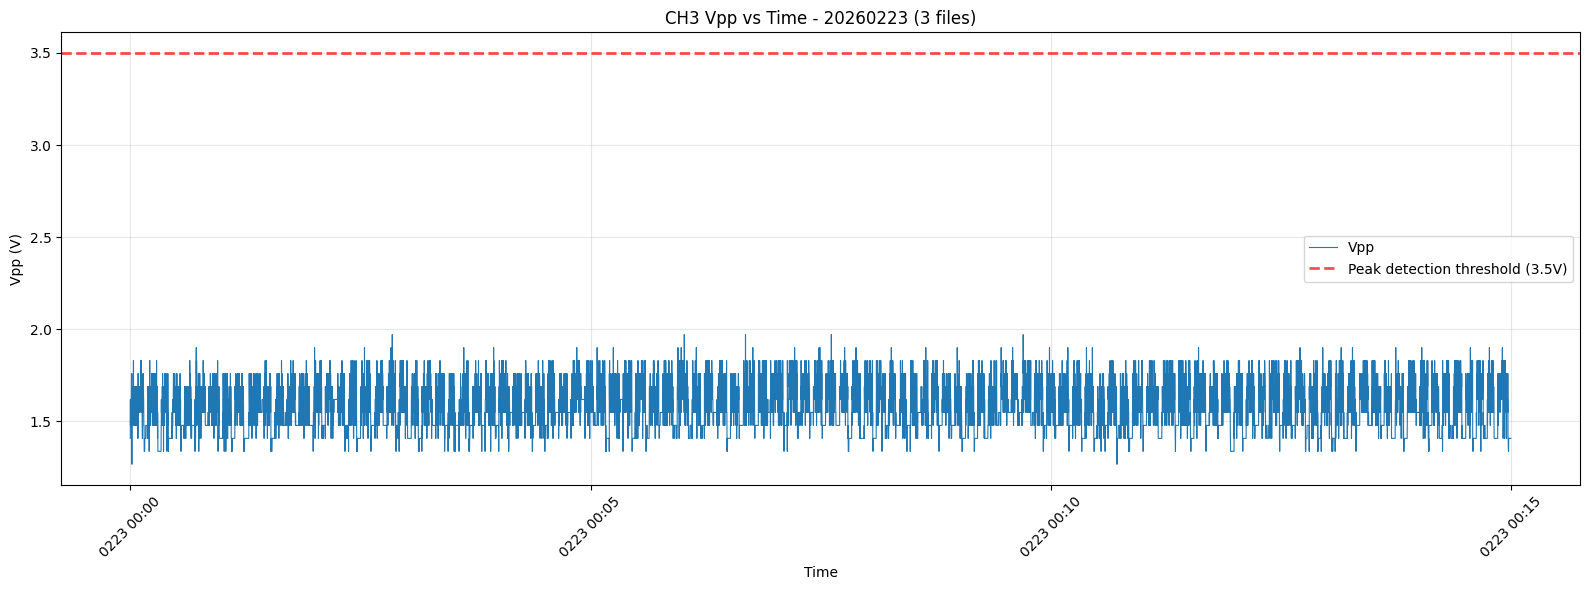


Found 0 peak(s) with Vpp > 3.5 V
No peaks found for this folder

✓ Folder '20260223' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260223

[30/30] Processing folder: 20260224
Found 288 total video file(s)
Processing 3 file(s) (limited by max_files=3)

[1/3] 20260224_000000_n.mkv
  ✓ Vpp range: 1.267 - 4.152 V

[2/3] 20260224_000500_n.mkv
  ✓ Vpp range: 1.337 - 2.674 V

[3/3] 20260224_001000_n.mkv
  ✓ Vpp range: 1.196 - 3.730 V

COMBINED DATA: 18000 samples
Vpp range: 1.196 - 4.152 V
Time span: 2026-02-24 00:00:00 to 2026-02-24 00:14:59.950000


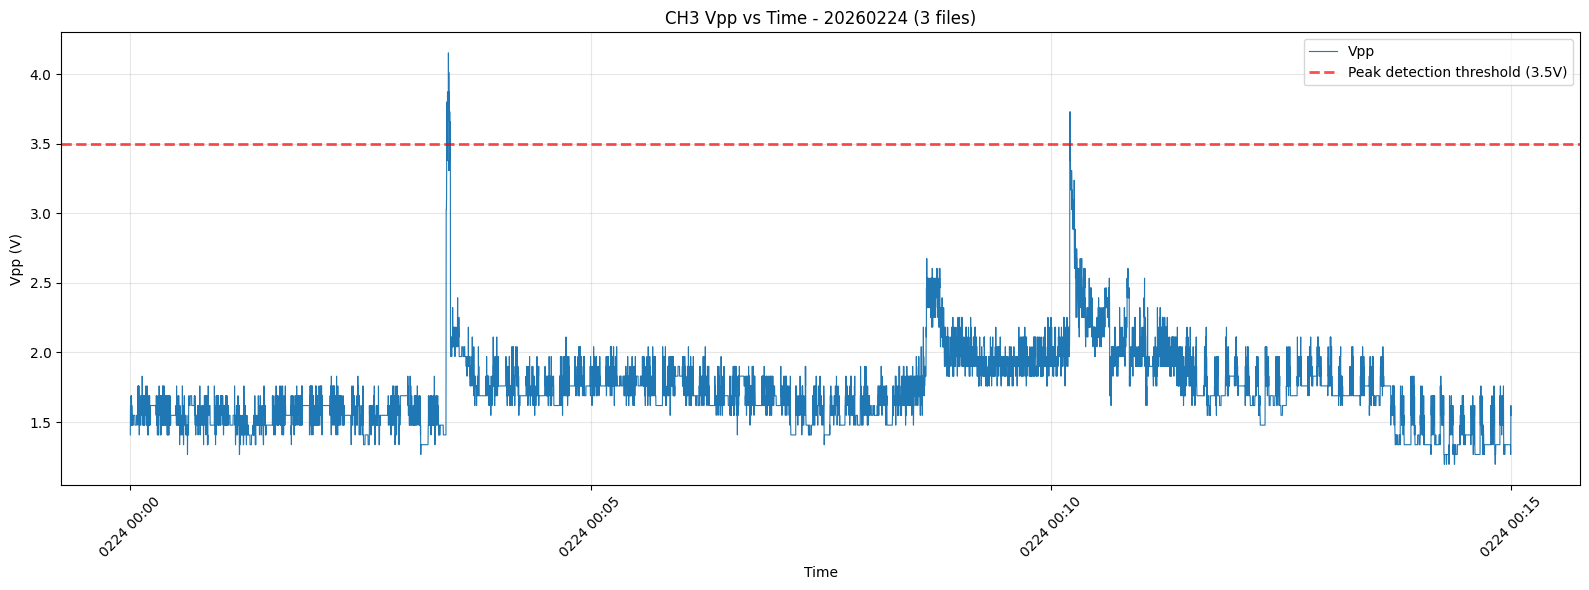


Found 3 peak(s) with Vpp > 3.5 V

PEAK SUMMARY
Peak 1: 2026-02-24 00:03:27 → Vpp = 4.1524 V
Peak 2: 2026-02-24 00:03:28 → Vpp = 3.6597 V
Peak 3: 2026-02-24 00:10:12 → Vpp = 3.7301 V

✓ Peak summary saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260224_peak_summary.csv
✓ Peak summary plot saved to: /Users/xylu/Desktop/Data/acoustic_vpp/summary/20260224_peak_summary_plot.png

✓ Folder '20260224' complete! Data saved to: /Users/xylu/Desktop/Data/acoustic_vpp/20260224

ALL FOLDERS PROCESSED!


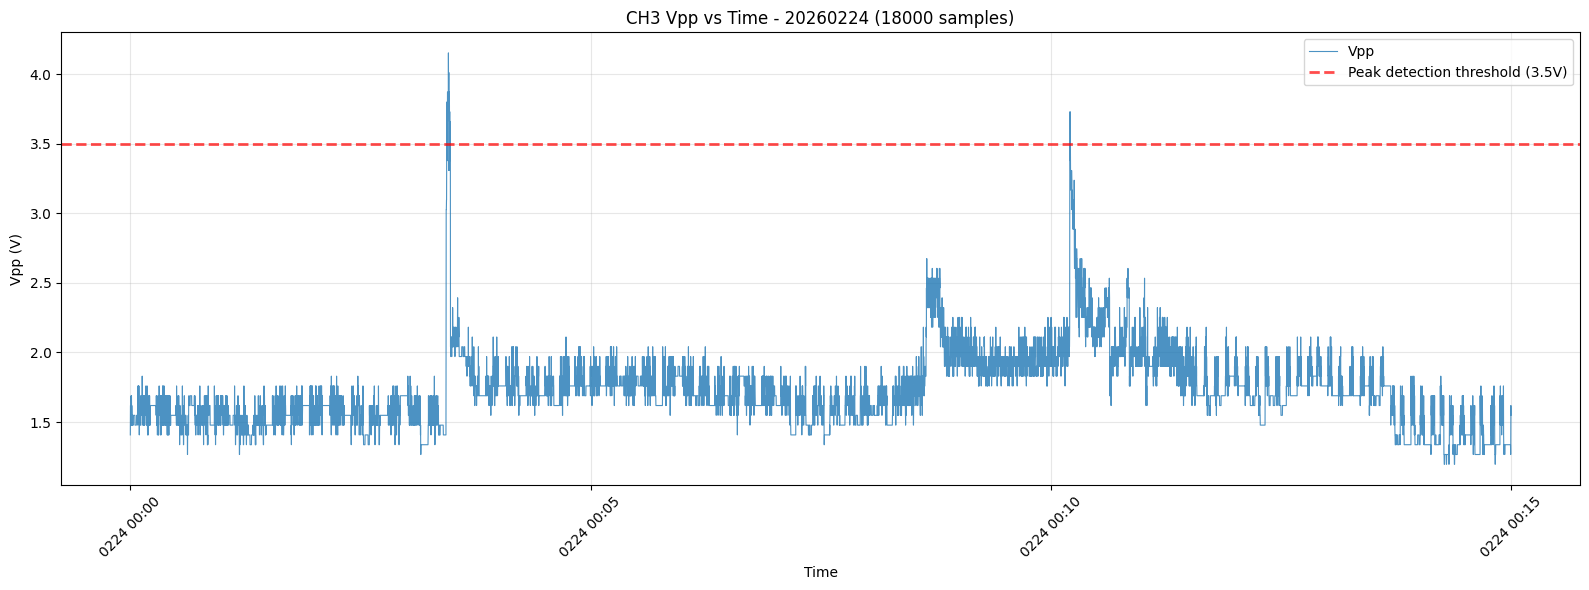

In [6]:
# Get all subfolders in parent directory
subfolders = sorted([f.path for f in os.scandir(parent_folder) if f.is_dir()])
print(f"Found {len(subfolders)} folder(s) in: {parent_folder}")
print("="*60)

for folder_idx, video_folder in enumerate(subfolders):
    folder_name = os.path.basename(video_folder.rstrip('/'))
    print(f"\n{'='*60}")
    print(f"[{folder_idx + 1}/{len(subfolders)}] Processing folder: {folder_name}")
    print("="*60)
    
    # Find all .mkv files
    mkv_files = sorted(glob.glob(os.path.join(video_folder, "*.mkv")))
    print(f"Found {len(mkv_files)} total video file(s)")
    
    if len(mkv_files) == 0:
        print("  ⚠ No .mkv files found, skipping folder")
        continue
    
    # Create output folder based on video folder name
    output_folder = f"/Users/xylu/Desktop/Data/acoustic_vpp/{folder_name}"
    os.makedirs(output_folder, exist_ok=True)
    
    # Process files
    if max_files is None:
        mkv_files_to_process = mkv_files
        print(f"Processing all {len(mkv_files_to_process)} file(s)")
    else:
        mkv_files_to_process = mkv_files[:max_files]
        print(f"Processing {len(mkv_files_to_process)} file(s) (limited by max_files={max_files})")
    print("="*60)
    
    # Container for combined data
    all_time_datetime = []
    all_vpp_data = []
    file_info = []
    
    for file_idx, file_path in enumerate(mkv_files_to_process):
        basename = os.path.basename(file_path)
        print(f"\n[{file_idx + 1}/{len(mkv_files_to_process)}] {basename}")
        
        # Extract start time
        start_dt = extract_datetime_from_filename(basename)
        if start_dt is None:
            print(f"  ⚠ Skipped: Could not extract datetime")
            continue
        
        # Compute Vpp series
        try:
            time_s, vpp_data = compute_vpp_series_for_file(
                file_path,
                v_div=v_div,
                fps=fps,
                threshold=profile_threshold,
            )
            
            # Convert time to datetime
            time_datetime_data = np.array([start_dt + timedelta(seconds=t) for t in time_s])
            
            # Accumulate data
            all_time_datetime.extend(time_datetime_data)
            all_vpp_data.extend(vpp_data)
            
            # Create DataFrame for individual file
            df = pd.DataFrame({
                'time_datetime': time_datetime_data.astype(str),
                'time_seconds': time_s,
                'vpp_volts': vpp_data
            })
            
            # Save individual CSV
            csv_filename = basename.replace('.mkv', '_vpp.csv')
            csv_filepath = os.path.join(output_folder, csv_filename)
            df.to_csv(csv_filepath, index=False)
            
            vpp_min, vpp_max = np.nanmin(vpp_data), np.nanmax(vpp_data)
            print(f"  ✓ Vpp range: {vpp_min:.3f} - {vpp_max:.3f} V")
            file_info.append((basename, start_dt, vpp_min, vpp_max))
            
        except Exception as e:
            print(f"  ✗ Error: {str(e)}")
    
    # Convert to arrays
    all_time_datetime = np.array(all_time_datetime)
    all_vpp_data = np.array(all_vpp_data)
    
    print("\n" + "="*60)
    print(f"COMBINED DATA: {len(all_vpp_data)} samples")
    if len(all_vpp_data) > 0:
        print(f"Vpp range: {np.nanmin(all_vpp_data):.3f} - {np.nanmax(all_vpp_data):.3f} V")
        print(f"Time span: {all_time_datetime[0]} to {all_time_datetime[-1]}")
    print("="*60)
    
    # Plot combined Vpp vs time
    if len(all_vpp_data) > 0:
        fig, ax = plt.subplots(figsize=(16, 6))
        ax.plot(all_time_datetime, all_vpp_data, linewidth=0.8, label='Vpp')
        ax.axhline(y=3.5, color='r', linestyle='--', linewidth=2, alpha=0.7, label='Peak detection threshold (3.5V)')
        ax.set_title(f"CH3 Vpp vs Time - {folder_name} ({len(mkv_files_to_process)} files)")
        ax.set_xlabel("Time")
        ax.set_ylabel("Vpp (V)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Find peaks across combined dataset
        vpp_peaks, peak_properties = find_peaks(all_vpp_data, height=3.5, distance=20)
        print(f"\nFound {len(vpp_peaks)} peak(s) with Vpp > 3.5 V")
        print("="*60)
        
        if len(vpp_peaks) > 0:
            # Peak summary
            print("\n" + "="*60)
            print("PEAK SUMMARY")
            print("="*60)
            for peak_idx, sample_idx in enumerate(vpp_peaks):
                peak_time = all_time_datetime[sample_idx]
                vpp_val = all_vpp_data[sample_idx]
                print(f"Peak {peak_idx + 1}: {peak_time.strftime('%Y-%m-%d %H:%M:%S')} → Vpp = {vpp_val:.4f} V")
            
            # Save peak summary and figure
            summary_folder = os.path.abspath(os.path.join(output_folder, '../summary/'))
            os.makedirs(summary_folder, exist_ok=True)
            
            # Prepare peak data for saving
            peak_data_list = []
            for peak_idx, sample_idx in enumerate(vpp_peaks):
                peak_time = all_time_datetime[sample_idx]
                vpp_val = all_vpp_data[sample_idx]
                
                peak_data_list.append({
                    'peak_number': peak_idx + 1,
                    'frame_sample_idx': int(sample_idx),
                    'time_datetime': peak_time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3],
                    'vpp_volts': float(vpp_val)
                })
            
            # Save peak list to CSV
            peak_df = pd.DataFrame(peak_data_list)
            peak_csv_path = os.path.join(summary_folder, f"{folder_name}_peak_summary.csv")
            peak_df.to_csv(peak_csv_path, index=False)
            print(f"\n✓ Peak summary saved to: {peak_csv_path}")
            
            # Create and save summary figure
            fig, ax = plt.subplots(figsize=(16, 6))
            ax.plot(all_time_datetime, all_vpp_data, linewidth=0.8, label='Vpp', alpha=0.8)
            ax.axhline(y=3.5, color='r', linestyle='--', linewidth=2, alpha=0.7, label='Peak detection threshold (3.5V)')
            ax.set_title(f"CH3 Vpp vs Time - {folder_name} ({len(all_vpp_data)} samples)")
            ax.set_xlabel("Time")
            ax.set_ylabel("Vpp (V)")
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m%d %H:%M'))
            plt.xticks(rotation=45)
            plt.tight_layout()
            plot_path = os.path.join(summary_folder, f"{folder_name}_peak_summary_plot.png")
            plt.savefig(plot_path, dpi=100, bbox_inches='tight')
            print(f"✓ Peak summary plot saved to: {plot_path}")
        else:
            print("No peaks found for this folder")
    
    print(f"\n✓ Folder '{folder_name}' complete! Data saved to: {output_folder}")

print("\n" + "="*60)
print("ALL FOLDERS PROCESSED!")
print("="*60)